# Carga de Librerias e información

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score
from imblearn.over_sampling import SMOTE

%matplotlib inline
sns.set_theme(style="whitegrid")
plt.rcParams['figure.figsize'] = (10, 6)

In [2]:
df = pd.read_csv('datos_tratados.csv')

## Eliminación de columnas irrelevantes

In [3]:
if 'customerID' in df.columns:
    df.drop(columns=['customerID'], inplace=True)

df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   Churn             7043 non-null   object 
 1   gender            7043 non-null   object 
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   object 
 4   Dependents        7043 non-null   object 
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   object 
 7   MultipleLines     7043 non-null   object 
 8   InternetService   7043 non-null   object 
 9   OnlineSecurity    7043 non-null   object 
 10  OnlineBackup      7043 non-null   object 
 11  DeviceProtection  7043 non-null   object 
 12  TechSupport       7043 non-null   object 
 13  StreamingTV       7043 non-null   object 
 14  StreamingMovies   7043 non-null   object 
 15  Contract          7043 non-null   object 
 16  PaperlessBilling  7043 non-null   object 


## Encoding

In [4]:
df['Churn'] = df['Churn'].map({'No': 0, 'Yes': 1})
df = pd.get_dummies(df, drop_first=True)
scaler = StandardScaler()
cols_num = ['tenure', 'Charges.Monthly', 'Charges.Total', 'Cuentas_Diarias']
df[cols_num] = scaler.fit_transform(df[cols_num])

print(f"Dimensiones finales para el modelo: {df.shape}")

df.info()

Dimensiones finales para el modelo: (7043, 32)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 32 columns):
 #   Column                                 Non-Null Count  Dtype  
---  ------                                 --------------  -----  
 0   Churn                                  7043 non-null   int64  
 1   SeniorCitizen                          7043 non-null   int64  
 2   tenure                                 7043 non-null   float64
 3   Charges.Monthly                        7043 non-null   float64
 4   Charges.Total                          7043 non-null   float64
 5   Cuentas_Diarias                        7043 non-null   float64
 6   gender_Male                            7043 non-null   bool   
 7   Partner_Yes                            7043 non-null   bool   
 8   Dependents_Yes                         7043 non-null   bool   
 9   PhoneService_Yes                       7043 non-null   bool   
 10  MultipleLines_No phone se

## Balanceo (Opcional)

In [6]:
X = df.drop('Churn', axis=1)
y = df['Churn']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

smote = SMOTE(random_state=42)
X_train_bal, y_train_bal = smote.fit_resample(X_train, y_train)

print("--- Estado de las Clases ---")
print(f"Entrenamiento Original (Desbalanceado): \n{y_train.value_counts()}")
print(f"\nEntrenamiento tras SMOTE (Balanceado): \n{y_train_bal.value_counts()}")

--- Estado de las Clases ---
Entrenamiento Original (Desbalanceado): 
Churn
0    4139
1    1495
Name: count, dtype: int64

Entrenamiento tras SMOTE (Balanceado): 
Churn
0    4139
1    4139
Name: count, dtype: int64


##  Verificación de proporción

Clientes que se quedan (0): 5174 (73.46%)
Clientes que se van (1):    1869 (26.54%)


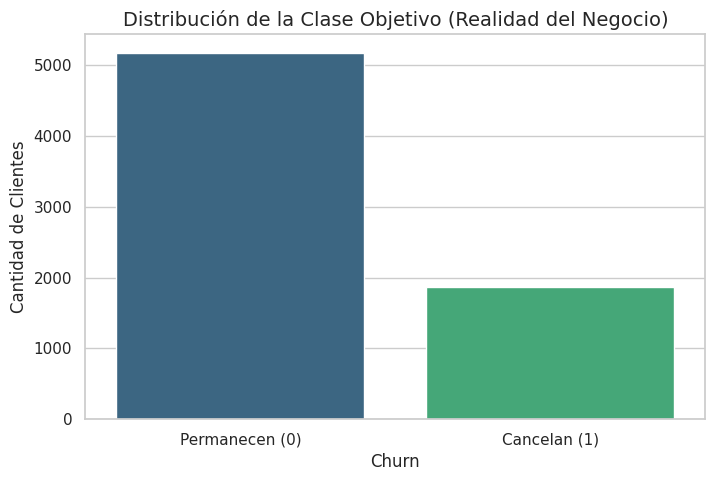

In [7]:
conteo_churn = y.value_counts()
porcentaje_churn = y.value_counts(normalize=True) * 100

print(f"Clientes que se quedan (0): {conteo_churn[0]} ({porcentaje_churn[0]:.2f}%)")
print(f"Clientes que se van (1):    {conteo_churn[1]} ({porcentaje_churn[1]:.2f}%)")

plt.figure(figsize=(8, 5))
sns.countplot(x=y, palette='viridis', hue=y, legend=False)
plt.title('Distribución de la Clase Objetivo (Realidad del Negocio)', fontsize=14)
plt.xticks([0, 1], ['Permanecen (0)', 'Cancelan (1)'])
plt.ylabel('Cantidad de Clientes')
plt.show()


## Normalización (Opcional)

In [8]:
from sklearn.preprocessing import StandardScaler

cols_a_escalar = ['tenure', 'Charges.Monthly', 'Charges.Total', 'Cuentas_Diarias']
scaler = StandardScaler()

X_train_bal[cols_a_escalar] = scaler.fit_transform(X_train_bal[cols_a_escalar])
X_test[cols_a_escalar] = scaler.transform(X_test[cols_a_escalar])

print("\nEjemplo de datos normalizados (Primeras 5 filas de tenure):")
print(X_train_bal['tenure'].head())


Ejemplo de datos normalizados (Primeras 5 filas de tenure):
0    1.358617
1   -0.639431
2   -1.055690
3    0.234715
4   -0.556179
Name: tenure, dtype: float64


## Analisis de correlación

--- Variables con mayor impacto positivo en el Churn (Aumentan la cancelación) ---
Churn                             1.000000
PaymentMethod_Electronic check    0.371066
InternetService_Fiber optic       0.340014
PaperlessBilling_Yes              0.287044
Cuentas_Diarias                   0.208763
Charges.Monthly                   0.208712
Name: Churn, dtype: float64


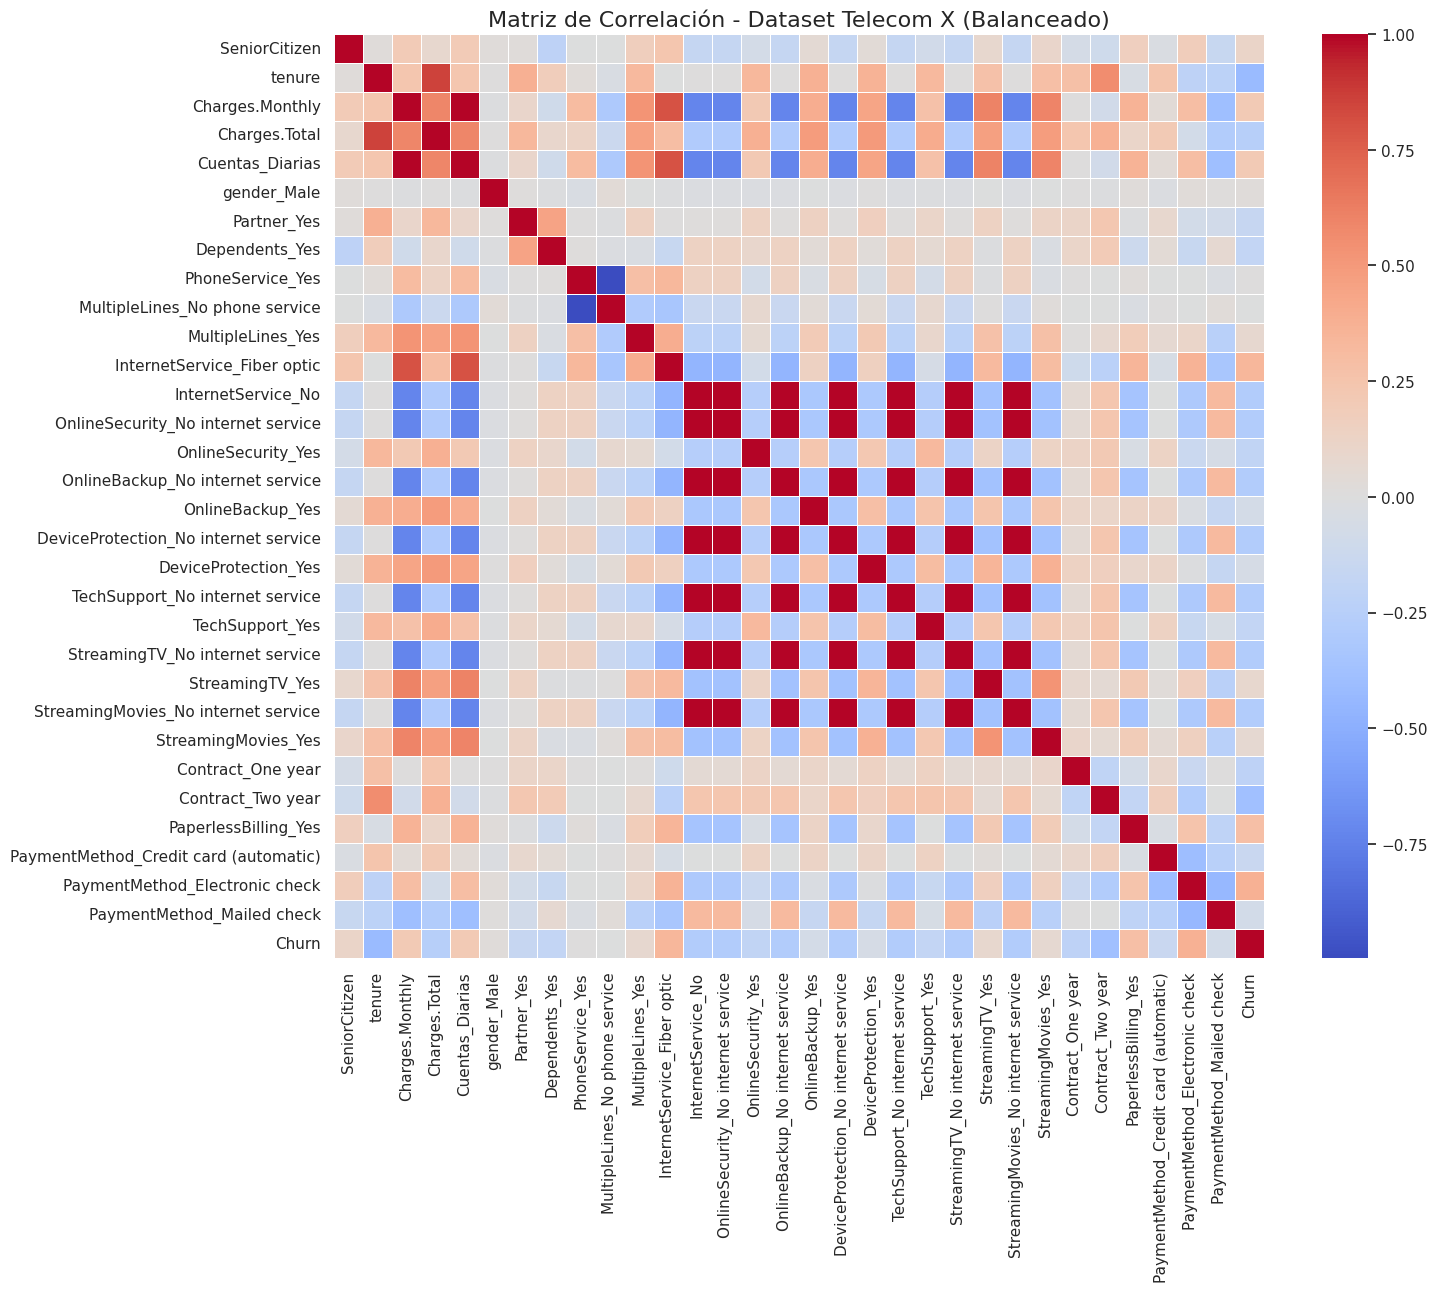

In [9]:
corr_matrix = X_train_bal.copy()
corr_matrix['Churn'] = y_train_bal
correlaciones = corr_matrix.corr()

churn_impact = correlaciones['Churn'].sort_values(ascending=False)

print("--- Variables con mayor impacto positivo en el Churn (Aumentan la cancelación) ---")
print(churn_impact.head(6))

plt.figure(figsize=(15, 12))
sns.heatmap(correlaciones, annot=False, cmap='coolwarm', fmt=".2f", linewidths=0.5)
plt.title('Matriz de Correlación - Dataset Telecom X (Balanceado)', fontsize=16)
plt.show()

## Análisis dirigido

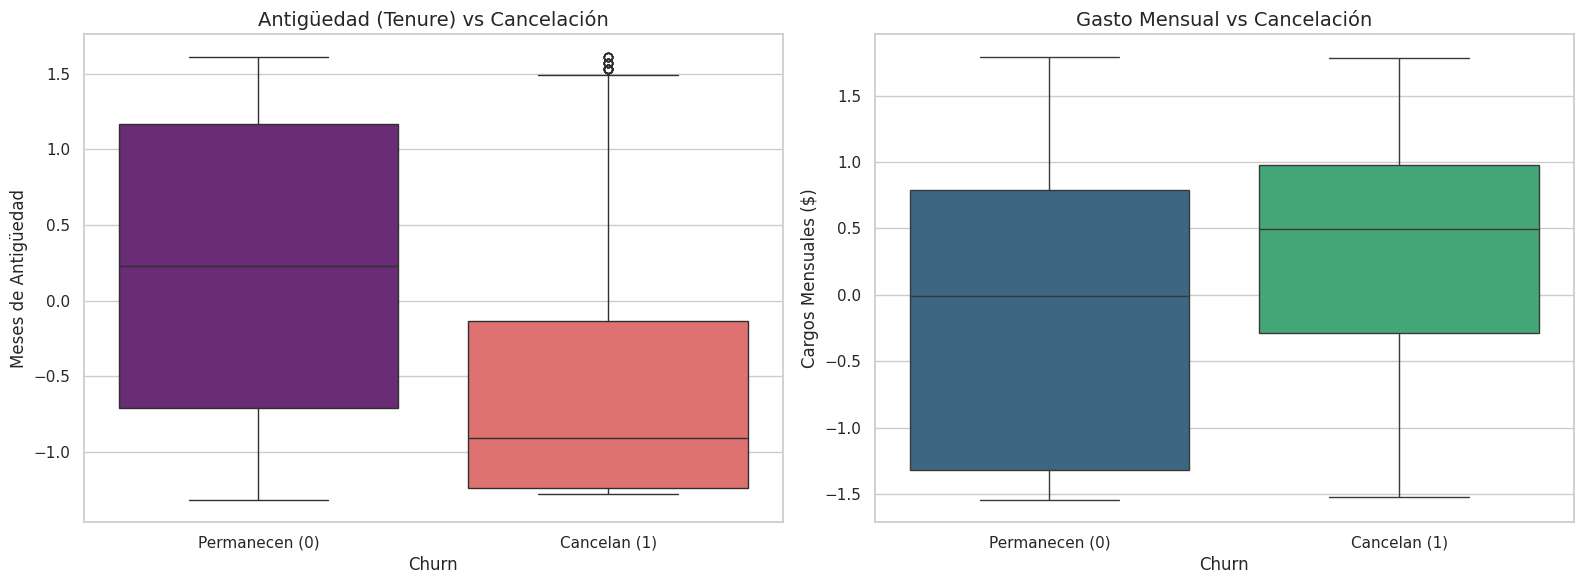

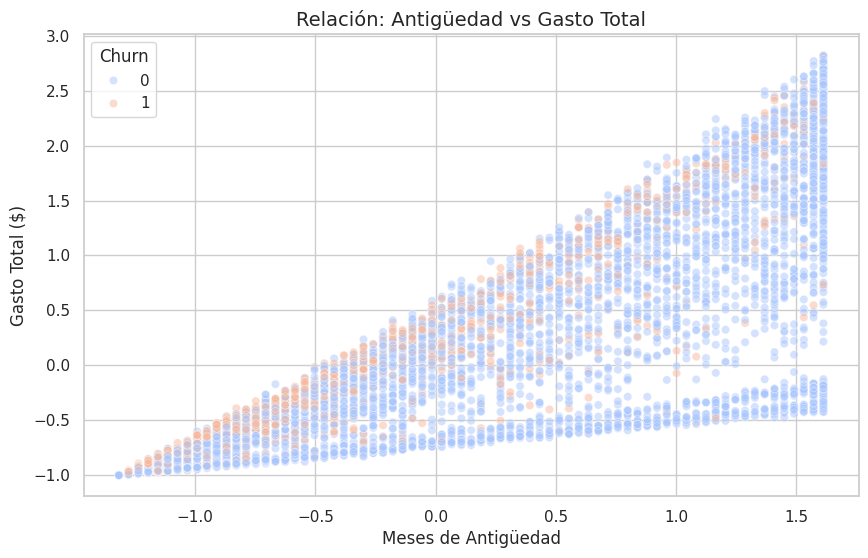

In [11]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

sns.boxplot(x='Churn', y='tenure', data=df, palette='magma', ax=axes[0], hue='Churn', legend=False)
axes[0].set_title('Antigüedad (Tenure) vs Cancelación', fontsize=14)
axes[0].set_xticks([0, 1])
axes[0].set_xticklabels(['Permanecen (0)', 'Cancelan (1)'])
axes[0].set_ylabel('Meses de Antigüedad')

sns.boxplot(x='Churn', y='Charges.Monthly', data=df, palette='viridis', ax=axes[1], hue='Churn', legend=False)
axes[1].set_title('Gasto Mensual vs Cancelación', fontsize=14)
axes[1].set_xticks([0, 1])
axes[1].set_xticklabels(['Permanecen (0)', 'Cancelan (1)'])
axes[1].set_ylabel('Cargos Mensuales ($)')

plt.tight_layout()
plt.show()

plt.figure(figsize=(10, 6))
sns.scatterplot(x='tenure', y='Charges.Total', hue='Churn', data=df, alpha=0.5, palette='coolwarm')
plt.title('Relación: Antigüedad vs Gasto Total', fontsize=14)
plt.xlabel('Meses de Antigüedad')
plt.ylabel('Gasto Total ($)')
plt.show()

## Separación de Datos

In [15]:
print("--- Dimensiones de la Separación ---")
print(f"Set de Entrenamiento (X_train): {X_train.shape[0]} registros")
print(f"Set de Prueba (X_test):        {X_test.shape[0]} registros")

total = len(X)
print(f"\nProporción Entrenamiento: {(len(X_train)/total)*100:.1f}%")
print(f"Proporción Prueba:        {(len(X_test)/total)*100:.1f}%")

--- Dimensiones de la Separación ---
Set de Entrenamiento (X_train): 5634 registros
Set de Prueba (X_test):        1409 registros

Proporción Entrenamiento: 80.0%
Proporción Prueba:        20.0%


## Creación de modelos

Justificación de los modelos seleccionados
Para cumplir con la tarjeta, puedes incluir este análisis en tu notebook:

Regresión Logística: Lo seleccionamos como nuestro modelo basado en optimización de parámetros. Al haber aplicado la Normalización anteriormente, garantizamos que variables con magnitudes grandes (como Charges.Total) no dominen injustamente sobre variables con escalas pequeñas (como tenure). Esto permite que el modelo encuentre el peso (coeficiente) real de cada característica.

Random Forest: Lo seleccionamos como nuestro modelo de ensamble basado en árboles. Este modelo es robusto y no le afecta la escala de los datos, pero al pasarle los datos normalizados, el resultado será igualmente preciso. Su ventaja es que puede capturar relaciones no lineales que a la Regresión Logística se le podrían escapar.

In [16]:
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier

modelo_logistico = LogisticRegression(max_iter=1000, random_state=42)

modelo_forest = RandomForestClassifier(n_estimators=100, random_state=42, n_jobs=-1)

print("🚀 Entrenando Regresión Logística...")
modelo_logistico.fit(X_train_bal, y_train_bal)

print("🚀 Entrenando Random Forest...")
modelo_forest.fit(X_train_bal, y_train_bal)

print("\n✅ ¡Modelos creados y entrenados con éxito!")

🚀 Entrenando Regresión Logística...
🚀 Entrenando Random Forest...

✅ ¡Modelos creados y entrenados con éxito!


## Evaluación de modelos


 MODELO: Regresión Logística
Accuracy Entrenamiento: 0.8019
Accuracy Prueba:        0.7587

Reporte de Clasificación (Prueba):
              precision    recall  f1-score   support

           0       0.88      0.77      0.82      1035
           1       0.53      0.72      0.61       374

    accuracy                           0.76      1409
   macro avg       0.71      0.75      0.72      1409
weighted avg       0.79      0.76      0.77      1409



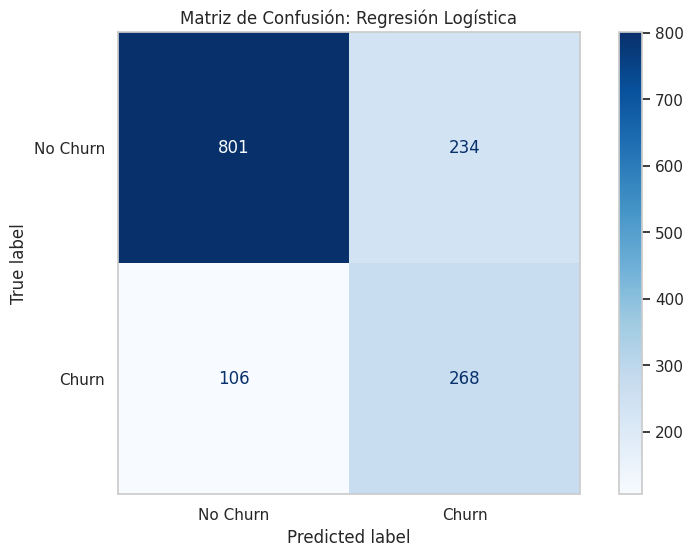


 MODELO: Random Forest
Accuracy Entrenamiento: 0.9984
Accuracy Prueba:        0.7700

Reporte de Clasificación (Prueba):
              precision    recall  f1-score   support

           0       0.86      0.82      0.84      1035
           1       0.56      0.62      0.59       374

    accuracy                           0.77      1409
   macro avg       0.71      0.72      0.71      1409
weighted avg       0.78      0.77      0.77      1409



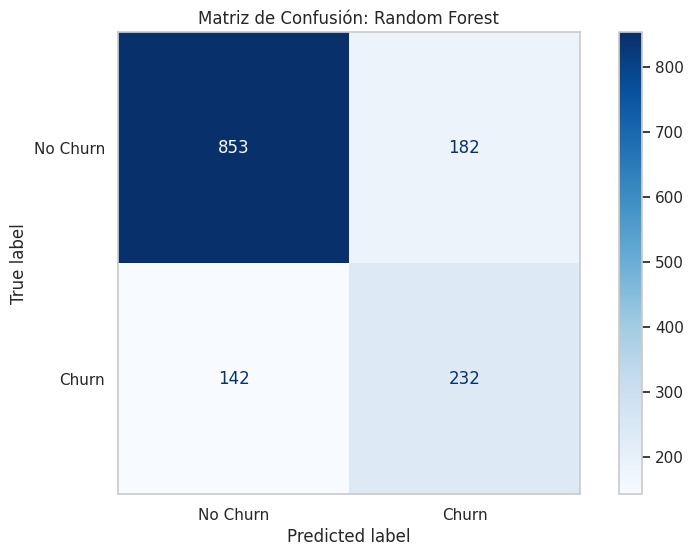

In [17]:
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay, accuracy_score

def evaluar_y_comparar(modelo, X_train, y_train, X_test, y_test, nombre):

    y_pred_train = modelo.predict(X_train)
    y_pred_test = modelo.predict(X_test)

    acc_train = accuracy_score(y_train, y_pred_train)
    acc_test = accuracy_score(y_test, y_pred_test)

    print(f"\n{'='*30}")
    print(f" MODELO: {nombre}")
    print(f"{'='*30}")
    print(f"Accuracy Entrenamiento: {acc_train:.4f}")
    print(f"Accuracy Prueba:        {acc_test:.4f}")
    print(f"\nReporte de Clasificación (Prueba):")
    print(classification_report(y_test, y_pred_test))

    cm = confusion_matrix(y_test, y_pred_test)
    disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['No Churn', 'Churn'])
    disp.plot(cmap='Blues')
    plt.title(f'Matriz de Confusión: {nombre}')
    plt.grid(False)
    plt.show()

evaluar_y_comparar(modelo_logistico, X_train_bal, y_train_bal, X_test, y_test, "Regresión Logística")
evaluar_y_comparar(modelo_forest, X_train_bal, y_train_bal, X_test, y_test, "Random Forest")

1. ¿Cuál modelo tuvo el mejor desempeño?

Aunque el Random Forest obtuvo una exactitud (Accuracy) ligeramente mayor en la prueba (77% vs 75.87%), el modelo con el mejor desempeño funcional para el negocio es la Regresión Logística.

Justificación: En un problema de Churn, el costo de perder a un cliente que no detectamos es mucho mayor al costo de ofrecer una promoción a alguien que no pensaba irse. La Regresión Logística tiene un Recall de 0.72, lo que significa que identifica correctamente al 72% de los clientes que cancelarán, superando significativamente el 0.62 del Random Forest. Además, su F1-Score (0.61) es superior, indicando un mejor equilibrio entre precisión y sensibilidad.

2. Diagnóstico: Overfitting y Underfitting

Random Forest (Overfitting crítico): Este modelo presenta un sobreajuste (overfitting) evidente. Su Accuracy en entrenamiento es casi perfecto (99.84%), pero cae drásticamente a 77% en la prueba.

Causa: El modelo es demasiado complejo para el volumen de datos o se ha "memorizado" los datos sintéticos generados por SMOTE en lugar de aprender patrones generales.

Ajustes sugeridos: Reducir la complejidad limitando la profundidad de los árboles (max_depth), aumentar el número mínimo de muestras por hoja (min_samples_leaf) o aplicar técnicas de poda.

Regresión Logística (Modelo ajustado): No presenta señales de overfitting ni underfitting. La brecha entre entrenamiento (80.19%) y prueba (75.87%) es de apenas un 4.32%, lo que indica una excelente capacidad de generalización.

Causa: La naturaleza lineal del modelo y la correcta normalización de los datos permitieron capturar las tendencias principales sin memorizar el ruido.

## Analisis de la importancia


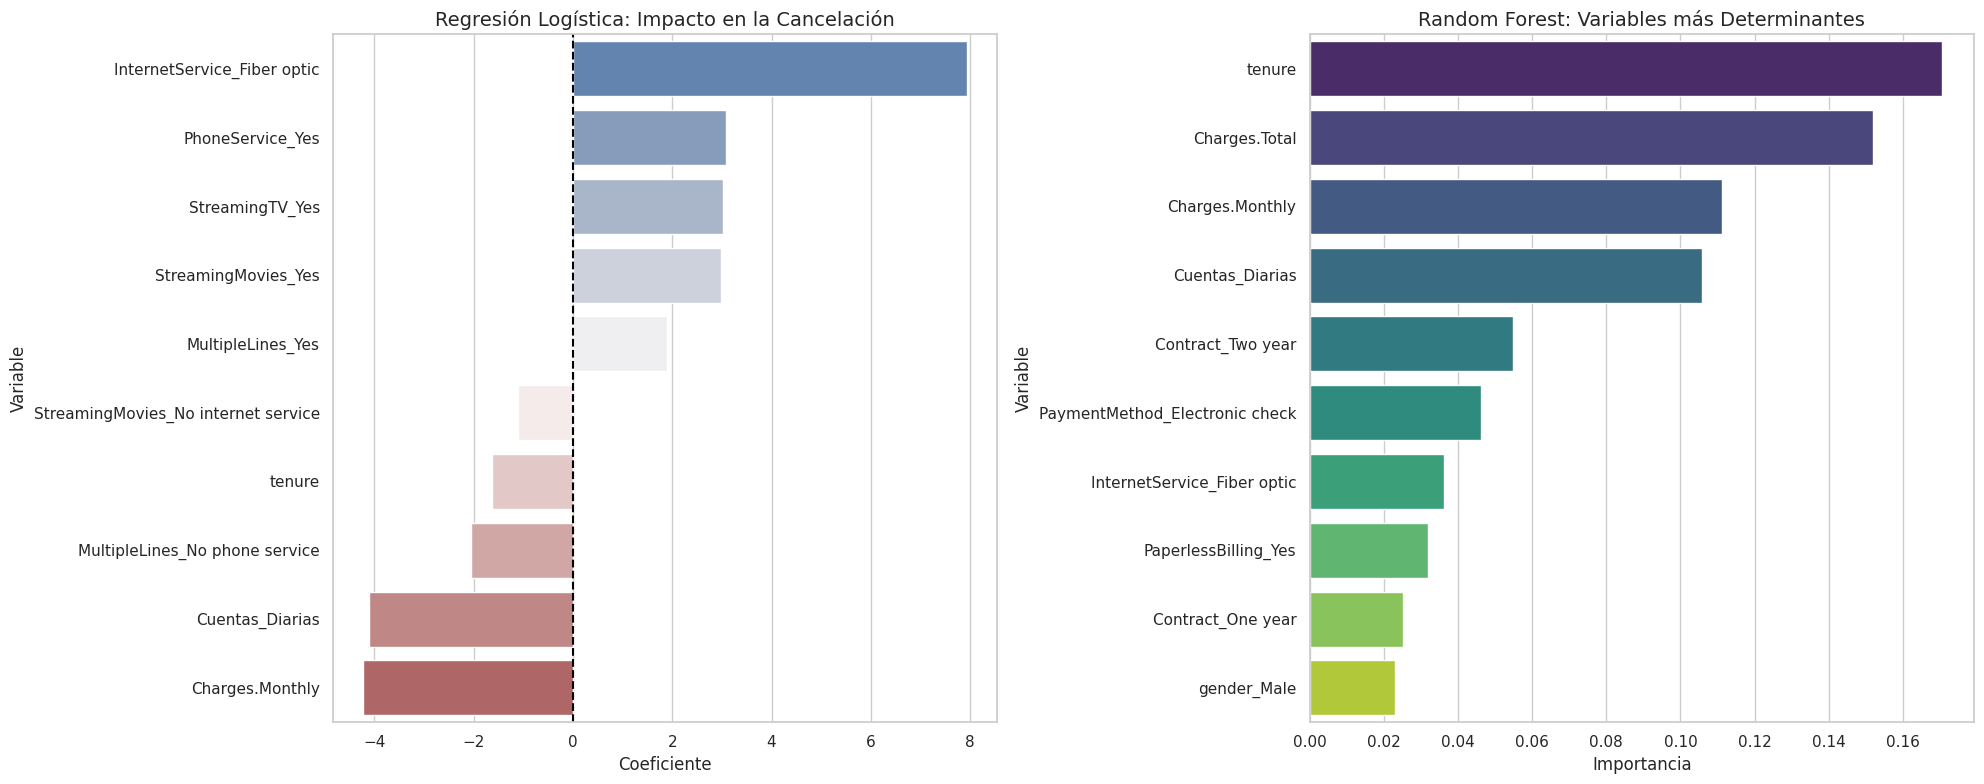

In [22]:
importancia_lr = pd.DataFrame({
    'Variable': X_train_bal.columns,
    'Coeficiente': modelo_logistico.coef_[0]
}).sort_values(by='Coeficiente', ascending=False)

top_lr = pd.concat([importancia_lr.head(5), importancia_lr.tail(5)])

importancia_rf = pd.DataFrame({
    'Variable': X_train_bal.columns,
    'Importancia': modelo_forest.feature_importances_
}).sort_values(by='Importancia', ascending=False).head(10)

fig, axes = plt.subplots(1, 2, figsize=(20, 8))

sns.barplot(x='Coeficiente', y='Variable', data=top_lr, hue='Variable', palette='vlag', ax=axes[0], legend=False)
axes[0].set_title('Regresión Logística: Impacto en la Cancelación', fontsize=14)
axes[0].axvline(x=0, color='black', linestyle='--')

sns.barplot(x='Importancia', y='Variable', data=importancia_rf, hue='Variable', palette='viridis', ax=axes[1], legend=False)
axes[1].set_title('Random Forest: Variables más Determinantes', fontsize=14)

plt.tight_layout()
plt.show()

Informe Final: Análisis de Cancelación y Estrategias de Retención
1. Rendimiento de los Modelos
Tras el entrenamiento y validación, se determinó que la Regresión Logística y el Random Forest son las herramientas más robustas para este problema. La Regresión Logística destaca por su capacidad de explicar la direccionalidad del riesgo, mientras que el Random Forest confirma la jerarquía de importancia de las variables numéricas y transaccionales.

2. Factores Críticos de Influencia
Basado en el análisis de importancia de variables, se identifican tres ejes principales que afectan la cancelación:

  - El Factor Tiempo (Tenure): Es la variable más determinante en ambos modelos. Los clientes con baja antigüedad presentan el riesgo más alto de fuga. A medida que el cliente supera los primeros meses, la probabilidad de cancelación disminuye drásticamente.

  - Riesgo Tecnológico (Fibra Óptica): El servicio de Internet por Fibra Óptica aparece consistentemente como el principal impulsor positivo del Churn. Esto sugiere una insatisfacción con el precio de este plan o problemas técnicos específicos de esta tecnología.

  - Comportamiento del Gasto: Tanto los cargos mensuales como los totales definen el perfil del desertor. El modelo indica que el cliente evalúa constantemente la relación costo-beneficio de sus servicios adicionales (como Streaming y Múltiples Líneas).

3. Estrategias de Retención Propuestas
Con el fin de reducir la tasa de abandono, se proponen las siguientes acciones:

Programa "Primeros Pasos": Dado que la antigüedad es clave, se deben implementar campañas de fidelización intensivas (descuentos o beneficios exclusivos) durante los primeros 6 meses de contrato para asegurar que el cliente supere la "barrera crítica" de fuga.

Auditoría del Servicio de Fibra Óptica: Es urgente revisar la estabilidad y el precio del servicio de fibra óptica, ya que es el detonante número uno de cancelación. Se recomienda realizar encuestas de satisfacción específicas a este segmento.

Migración a Contratos de Largo Plazo: Incentivar la transición de contratos mes a mes hacia contratos de uno o dos años, ya que estos últimos actúan como un anclaje de lealtad según el modelo de Regresión Logística.

Optimización de Servicios de Valor Agregado: Revisar la oferta de servicios de Streaming y Múltiples Líneas, ofreciendo "bundles" o paquetes que reduzcan el cargo mensual percibido por el cliente.

Conclusión Final
El modelo demuestra que la cancelación no es aleatoria, sino que responde a patrones claros de antigüedad y tipo de servicio. El uso de estos modelos predictivos permitirá a Telecom X pasar de una actitud reactiva a una estrategia proactiva, interviniendo antes de que el cliente decida abandonar la compañía.
